In [1]:
RESULT_PATH = "../output/result_1766691418_20251124F_20260101F_20251123_20251124.csv"

In [69]:
options(warn=0, error=recover)
install_if_missing <- function(pkg, github = NULL) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    message(sprintf("Installing package: %s", pkg))
    tryCatch({
      if (is.null(github)) {
        install.packages(pkg, repos = "https://cloud.r-project.org")
      } else {
        if (!requireNamespace("remotes", quietly = TRUE)) {
          install.packages("remotes", repos = "https://cloud.r-project.org")
        }
        remotes::install_github(github)
      }
    }, error = function(e) {
      message(sprintf("Failed to install %s: %s", pkg, e$message))
      return(NULL)
    })
  }
  if (requireNamespace(pkg, quietly = TRUE)) {
    library(pkg, character.only = TRUE)
  } else {
    message(sprintf("Package %s is still not available after attempted installation.", pkg))
  }
}
pkgs <- c("lme4","readr","marginaleffects","ggplot2","dplyr","gridExtra", "patchwork", "grid")
for (pkg in pkgs) {
  install_if_missing(pkg)
}
install_if_missing("showtext", github = "yixuan/showtext")
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: aarch64-apple-darwin20.0.0
Running under: macOS Sequoia 15.6.1

Matrix products: default
BLAS/LAPACK: /Users/zory/miniforge3/envs/gaze/lib/libopenblas.0.dylib;  LAPACK version 3.12.0

locale:
[1] C/C.UTF-8/C/C/C/C

time zone: Asia/Shanghai
tzcode source: system (macOS)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] effectsize_1.0.1       showtext_0.9-7         showtextdb_3.0        
 [4] sysfonts_0.8.9         patchwork_1.3.2        gridExtra_2.3         
 [7] dplyr_1.1.4            ggplot2_4.0.1          marginaleffects_0.31.0
[10] readr_2.1.6            lme4_1.1-38            Matrix_1.7-4          

loaded via a namespace (and not attached):
 [1] generics_0.1.4     lattice_0.22-7     hms_1.1.4          digest_0.6.39     
 [5] magrittr_2.0.4     evaluate_1.0.5     RColorBrewer_1.1-3 pbdZMQ_0.3-14     
 [9] fastmap_1.2.0      jsonlite_2.0.0     backpor

In [14]:
colors <- c("#B83945","#92A5D1","#4F845C","#DAA87C","#D9B9D4",
            "#C9DCC4","#377483","#F4EEAC","#E3E457","#AEB2D1",
            "#7C9895","#C5DFF4")

# register DejaVuSerif
sysfonts::font_add("DejaVuSerif", regular = "./other/DejaVuSerif.ttf", bold = "./other/DejaVuSerif-Bold.ttf")
showtext::showtext_auto()

# theme
theme_serif_bold <- function(){
  theme_minimal(base_family="DejaVuSerif", base_size=14) +
    theme(
      text          = element_text(face="bold"),
      axis.title    = element_text(face="bold"),
      axis.text     = element_text(face="bold"),
      legend.text   = element_text(face="bold"),
      legend.title  = element_text(face="bold"),
      panel.grid.major = element_line(color="grey90"),
      panel.grid.minor = element_blank()
    )
}

GROUP_LIST <- c(
  "GLM-4.6V-Flash-gaze2",
  "gpt-5.2-gaze2",
  "gpt-4o-2024-08-06-gaze2",
  "Qwen3-VL-30B-A3B-Instruct-gaze2",
  "internlm-xcomposer2-vl-7b-gaze2"
)

api_to_name <- list(
  "gpt-5.2-gaze2" = "GPT-5.2",
  "gpt-4o-2024-08-06-gaze2" = "GPT-4o",
  "Qwen3-VL-30B-A3B-Instruct-gaze2" = "Qwen3",
  "internlm-xcomposer2-vl-7b-gaze2" = "InternLM",
  "GLM-4.6V-Flash-gaze2" = "GLM-4.6V"
)

In [19]:
df <- read_csv(RESULT_PATH, na = "", show_col_types = FALSE, col_types = cols(
    Stimulus_ID = col_factor(),
    Prompt_ID = col_integer()))
df$offset_accuracy <- qlogis(1 / df$n_candidates)
df$offset_wrongness <- qlogis(df$Wrongness_exp / df$Wrongness_max)
df$ActorSite <- interaction(df$Actor, df$Site, drop = TRUE)
df$Proximity_c <- scale(df$Proximity, scale = FALSE) # taking subset almost does not change the mean
df$n_candidates_c <- scale(df$n_candidates, scale = FALSE) # taking subset almost does not change the mean
strict_control <- glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))

In [20]:
df_B <- df[df$Site != "Site0", ] # take Stimuli B results only
df_B$Condition <- factor(ifelse(is.na(df_B$DistEyeHead), "natural", ifelse(df_B$DistEyeHead == 0, "congruent", "incongruent")), levels = c("natural", "congruent", "incongruent"))
df_replicate <- df_B[df_B$Condition != "incongruent", ]

In [10]:
# Compute baseline wrongness from the data
# Group by n_candidates and compute mean expected wrongness as a proportion
baseline_by_n_candidates <- df_replicate %>%
  filter(list_id != "-1", Part != "p0") %>%
  group_by(n_candidates) %>%
  summarise(baseline = mean(Wrongness_exp / Wrongness_max, na.rm = TRUE), .groups = 'drop')

# Extract individual baselines
baseline_wrongness_2 <- baseline_by_n_candidates %>% filter(n_candidates == 2) %>% pull(baseline)
baseline_wrongness_3 <- baseline_by_n_candidates %>% filter(n_candidates == 3) %>% pull(baseline)
baseline_wrongness_4 <- baseline_by_n_candidates %>% filter(n_candidates == 4) %>% pull(baseline)

# Compute overall baseline (mean across all trials)
baseline_wrongness_overall <- df_replicate %>%
  filter(list_id != "-1", Part != "p0") %>%
  summarise(baseline = mean(Wrongness_exp / Wrongness_max, na.rm = TRUE)) %>%
  pull(baseline)

cat("Baseline wrongness for n_candidates=2:", baseline_wrongness_2, "\n")
cat("Baseline wrongness for n_candidates=3:", baseline_wrongness_3, "\n")
cat("Baseline wrongness for n_candidates=4:", baseline_wrongness_4, "\n")
cat("Overall baseline wrongness:", baseline_wrongness_overall, "\n")

Baseline wrongness for n_candidates=2: 0.5 
Baseline wrongness for n_candidates=3: 0.5555556 
Baseline wrongness for n_candidates=4: 0.5 
Overall baseline wrongness: 0.5136364 


## Fitting models

In [21]:
get_formula <- function(grp){
  re <- if (grp=="gpt-4o-2024-08-06-gaze2") {
    "(1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Candidates)"
  } else {
    "(1 | Stimulus_ID)"
  }
  as.formula(paste0(
    "cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE)",
    " + Angle + scale(n_candidates, scale=FALSE) + Condition + offset(offset_wrongness) + ",
    re
  ))
}

models <- list()
for (grp in GROUP_LIST) {
  models[[grp]] <- lme4::glmer(
    get_formula(grp),
    data = df_replicate %>% filter(Group==grp, ),
    family = binomial(link="logit"), 
    control = strict_control
  )
}

# Prompt Analysis

In [99]:
df_no_order = df_replicate[(df_replicate$Prompt_ID %% 4) <= 1, ]
df_order = df_replicate[(df_replicate$Prompt_ID %% 4) > 1 & df_replicate$Prompt_ID != -1, ]
for (grp in GROUP_LIST) {
  print(grp)
  print(t.test(df_no_order$Accuracy[df_no_order$Group == grp],
               df_order$Accuracy[df_order$Group == grp],
               paired = TRUE,
               alternative = "two.sided",))
}

[1] "GLM-4.6V-Flash-gaze2"

	Paired t-test

data:  df_no_order$Accuracy[df_no_order$Group == grp] and df_order$Accuracy[df_order$Group == grp]
t = 2.0648, df = 5279, p-value = 0.03899
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 0.0004022365 0.0155068544
sample estimates:
mean difference 
    0.007954545 

[1] "gpt-5.2-gaze2"

	Paired t-test

data:  df_no_order$Accuracy[df_no_order$Group == grp] and df_order$Accuracy[df_order$Group == grp]
t = 3.7103, df = 5279, p-value = 0.0002091
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 0.01027223 0.03328837
sample estimates:
mean difference 
      0.0217803 

[1] "gpt-4o-2024-08-06-gaze2"

	Paired t-test

data:  df_no_order$Accuracy[df_no_order$Group == grp] and df_order$Accuracy[df_order$Group == grp]
t = 2.4771, df = 5279, p-value = 0.01328
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 0.003160

In [97]:
df_no_task = df_replicate[(df_replicate$Prompt_ID) < 8 & df_replicate$Prompt_ID != -1, ]
df_task = df_replicate[(df_replicate$Prompt_ID) >= 8, ]
for (grp in GROUP_LIST) {
  print(grp)
  print(t.test(df_no_task$Accuracy[df_no_task$Group == grp],
               df_task$Accuracy[df_task$Group == grp],
               paired = TRUE,
               alternative = "two.sided",))
}

[1] "GLM-4.6V-Flash-gaze2"

	Paired t-test

data:  df_no_task$Accuracy[df_no_task$Group == grp] and df_task$Accuracy[df_task$Group == grp]
t = 1.6554, df = 5279, p-value = 0.09791
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.001186635  0.014065422
sample estimates:
mean difference 
    0.006439394 

[1] "gpt-5.2-gaze2"

	Paired t-test

data:  df_no_task$Accuracy[df_no_task$Group == grp] and df_task$Accuracy[df_task$Group == grp]
t = 0.033201, df = 5279, p-value = 0.9735
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.01099361  0.01137240
sample estimates:
mean difference 
   0.0001893939 

[1] "gpt-4o-2024-08-06-gaze2"

	Paired t-test

data:  df_no_task$Accuracy[df_no_task$Group == grp] and df_task$Accuracy[df_task$Group == grp]
t = -1.4224, df = 5279, p-value = 0.155
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.020719204  0.0032

## Collect Marginal Effects

In [66]:
collect_trends <- function(models, variables, type){
  bind_rows(
    lapply(names(models), function(grp){
      marginaleffects::avg_slopes(
        models[[grp]],
        variables = variables,
        type = type,
        conf_level = 0.95
      ) %>%
      mutate(Group = api_to_name[[grp]])
    }),
    .id = NULL
  )
}

In [70]:
prox_resp_trend <- collect_trends(models, "Proximity",   "response")
prox_resp_trend %>% select(estimate, std.error, p.value, conf.low, conf.high, Group)

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning messa

estimate,std.error,p.value,conf.low,conf.high,Group
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
0.06416030,0.02160028,2.974649e-03,0.02182453,0.10649607,GLM-4.6V
0.08727849,0.01633238,9.097043e-08,0.05526763,0.11928936,GPT-5.2
0.07285438,0.01488289,9.821681e-07,0.04368446,0.10202431,GPT-4o
0.05333201,0.02156014,1.337447e-02,0.01107491,0.09558912,Qwen3
0.07781121,0.02036056,1.325545e-04,0.03790524,0.11771717,InternLM


In [71]:
obj_resp_trend  <- collect_trends(models, "n_candidates","response")
obj_resp_trend %>% select(estimate, std.error, p.value, conf.low, conf.high, Group)

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning messa

estimate,std.error,p.value,conf.low,conf.high,Group
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
0.03389819,0.02102620,0.10692096,-0.0073123997,0.07510879,GLM-4.6V
0.03713332,0.01621418,0.02201112,0.0053541149,0.06891253,GPT-5.2
0.02606770,0.01443197,0.07087967,-0.0022184293,0.05435384,GPT-4o
0.04124628,0.02124262,0.05217634,-0.0003884846,0.08288104,Qwen3
0.04535011,0.02029949,0.02547968,0.0055638394,0.08513638,InternLM


## Collect Marginal Means

In [72]:
collect_preds <- function(models, by, type){
  bind_rows(
    lapply(names(models), function(grp){
      marginaleffects::avg_predictions(
        models[[grp]],
        by = by,
        type = type,
        conf_level = 0.95
      ) %>%
      mutate(Group = api_to_name[[grp]])
    }),
    .id = NULL
  )
}

prox_resp <- collect_preds(models, "Proximity",   "response")
prox_link <- collect_preds(models, "Proximity",   "link")
obj_resp  <- collect_preds(models, "n_candidates","response")
obj_link  <- collect_preds(models, "n_candidates","link")
ang_resp  <- collect_preds(models, "Angle",       "response")
ang_link  <- collect_preds(models, "Angle",       "link")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning messa

In [73]:
prox_resp %>% select(estimate, std.error, p.value, conf.low, conf.high, Group)

estimate,std.error,p.value,conf.low,conf.high,Group
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
0.3455584,0.03063043,1.618892e-29,0.2855238,0.4055929,GLM-4.6V
0.3944859,0.02040702,2.952540e-83,0.3544889,0.4344829,GLM-4.6V
0.4347463,0.02572427,4.480698e-64,0.3843277,0.4851649,GLM-4.6V
0.3069234,0.02272810,1.478338e-41,0.2623772,0.3514697,GPT-5.2
0.3947216,0.01421196,8.966187e-170,0.3668667,0.4225765,GPT-5.2
0.4698096,0.02101263,9.994682e-111,0.4286256,0.5109936,GPT-5.2
0.3084317,0.02029498,3.677469e-52,0.2686542,0.3482091,GPT-4o
0.3845893,0.01241895,1.456912e-210,0.3602486,0.4089300,GPT-4o
0.4369028,0.01897126,2.349313e-117,0.3997198,0.4740857,GPT-4o


In [74]:
prox_link %>% select(estimate, std.error, p.value, conf.low, conf.high, Group)

estimate,std.error,p.value,conf.low,conf.high,Group
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
-1.5028387,0.2679437,2.037522e-08,-2.0279987,-0.97767862,GLM-4.6V
-0.9323438,0.1680844,2.908162e-08,-1.2617832,-0.60290435,GLM-4.6V
-0.6067566,0.2638403,2.146458e-02,-1.1238742,-0.08963907,GLM-4.6V
-1.3165019,0.1650311,1.495741e-15,-1.6399569,-0.99304690,GPT-5.2
-0.6466461,0.1036244,4.367621e-10,-0.8497461,-0.44354604,GPT-5.2
-0.1591212,0.1625181,3.275316e-01,-0.4776509,0.15940853,GPT-5.2
-1.1641534,0.1229400,2.817843e-21,-1.4051114,-0.92319535,GPT-4o
-0.7139941,0.0773317,2.634584e-20,-0.8655614,-0.56242674,GPT-4o
-0.3341955,0.1213608,5.891927e-03,-0.5720583,-0.09633279,GPT-4o


In [75]:
obj_resp %>% select(estimate, std.error, p.value, conf.low, conf.high, Group)

estimate,std.error,p.value,conf.low,conf.high,Group
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
0.3739496,0.01350329,8.424529e-169,0.3474837,0.4004156,GLM-4.6V
0.4354743,0.01801835,4.785882e-129,0.4001589,0.4707896,GLM-4.6V
0.3807664,0.03600056,3.822585e-26,0.3102066,0.4513262,GLM-4.6V
0.3620411,0.01555277,7.365090e-120,0.3315582,0.3925239,GPT-5.2
0.4256937,0.01417285,3.341560e-198,0.3979154,0.4534720,GPT-5.2
0.3932695,0.02406193,4.795888e-60,0.3461089,0.4404300,GPT-5.2
0.3364440,0.01677334,1.709606e-89,0.3035689,0.3693192,GPT-4o
0.4297200,0.01273866,1.863980e-249,0.4047527,0.4546873,GPT-4o
0.3776591,0.01977814,2.790813e-81,0.3388946,0.4164235,GPT-4o


In [76]:
obj_link %>% select(estimate, std.error, p.value, conf.low, conf.high, Group)

estimate,std.error,p.value,conf.low,conf.high,Group
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
-1.2929363,0.28440418,5.464315e-06,-1.8503583,-0.7355144,GLM-4.6V
-0.7426861,0.17092613,1.392310e-05,-1.0776951,-0.4076770,GLM-4.6V
-0.9518074,0.23399493,4.749142e-05,-1.4104291,-0.4931858,GLM-4.6V
-1.0277770,0.17526113,4.511378e-09,-1.3712825,-0.6842715,GPT-5.2
-0.4813445,0.10534390,4.894310e-06,-0.6878148,-0.2748743,GPT-5.2
-0.5867805,0.14456820,4.931525e-05,-0.8701289,-0.3034320,GPT-5.2
-1.0026308,0.13019663,1.351147e-14,-1.2578115,-0.7474501,GPT-4o
-0.4104937,0.07853126,1.721541e-07,-0.5644122,-0.2565753,GPT-4o
-0.7181190,0.10828978,3.323905e-11,-0.9303630,-0.5058749,GPT-4o


In [77]:
ang_resp %>% select(estimate, std.error, p.value, conf.low, conf.high, Group)

estimate,std.error,p.value,conf.low,conf.high,Group
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
0.3771039,0.03841665,9.593047e-23,0.3018086,0.4523991,GLM-4.6V
0.4366921,0.03007426,8.990794e-48,0.3777476,0.4956365,GLM-4.6V
0.3619794,0.02565622,3.350660e-45,0.3116941,0.4122647,GLM-4.6V
0.2836346,0.02852569,2.702113e-23,0.2277252,0.3395439,GPT-5.2
0.4596917,0.02273592,6.697191e-91,0.4151301,0.5042533,GPT-5.2
0.4296070,0.02028846,1.625829e-99,0.3898424,0.4693717,GPT-5.2
0.3366903,0.02405589,1.645017e-44,0.2895417,0.3838390,GPT-4o
0.4167651,0.01976614,1.096645e-98,0.3780242,0.4555060,GPT-4o
0.3779645,0.02029639,2.121001e-77,0.3381843,0.4177447,GPT-4o


In [78]:
ang_link %>% select(estimate, std.error, p.value, conf.low, conf.high, Group)

estimate,std.error,p.value,conf.low,conf.high,Group
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
-1.0648167,0.2866845,2.038110e-04,-1.6267081,-0.50292533,GLM-4.6V
-0.6505292,0.2904862,2.512667e-02,-1.2198717,-0.08118674,GLM-4.6V
-1.3151438,0.2944092,7.930153e-06,-1.8921751,-0.73811237,GLM-4.6V
-1.2827849,0.1769326,4.163576e-13,-1.6295663,-0.93600343,GPT-5.2
-0.3173738,0.1794250,7.692082e-02,-0.6690403,0.03429267,GPT-5.2
-0.5098875,0.1810805,4.865516e-03,-0.8647988,-0.15497617,GPT-5.2
-0.8904703,0.1323387,1.711608e-11,-1.1498494,-0.63109118,GPT-4o
-0.5583911,0.1344435,3.276401e-05,-0.8218955,-0.29488673,GPT-4o
-0.7533536,0.1341861,1.974237e-08,-1.0163536,-0.49035367,GPT-4o


## Approach 1: get marginal effects in logit probability space solely (recommended)
Calculating on the link (logit) scale and back-transforming. Will result in asymmetric error bars on the plot in the probability space. Safer than approach 2.

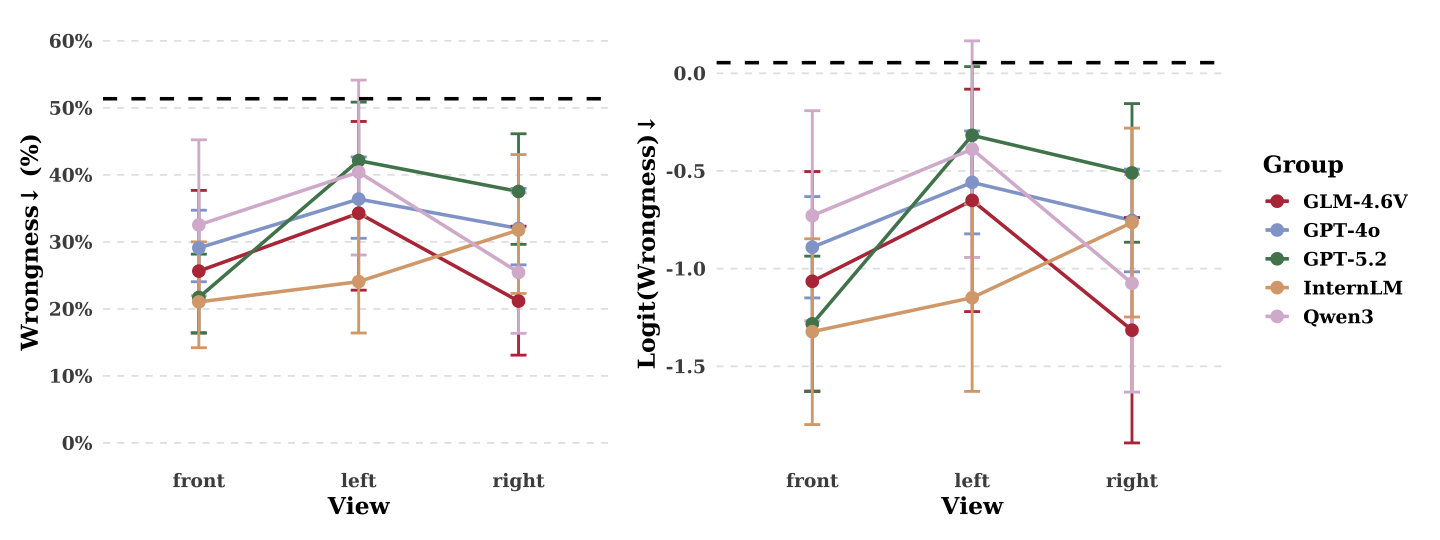

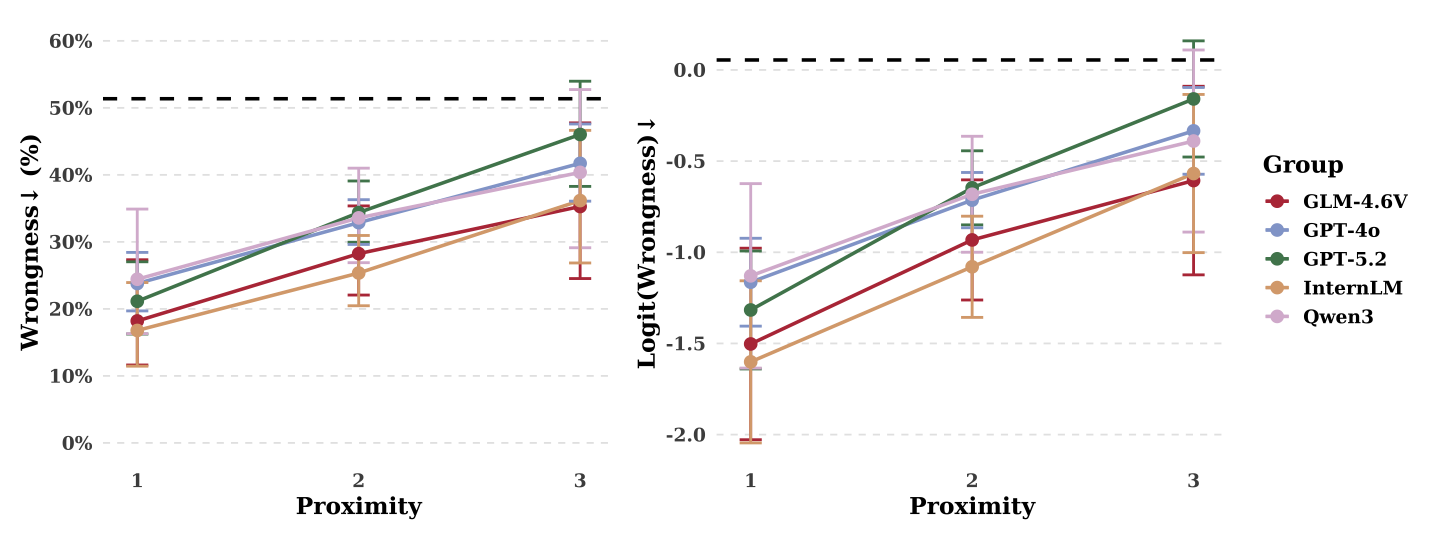

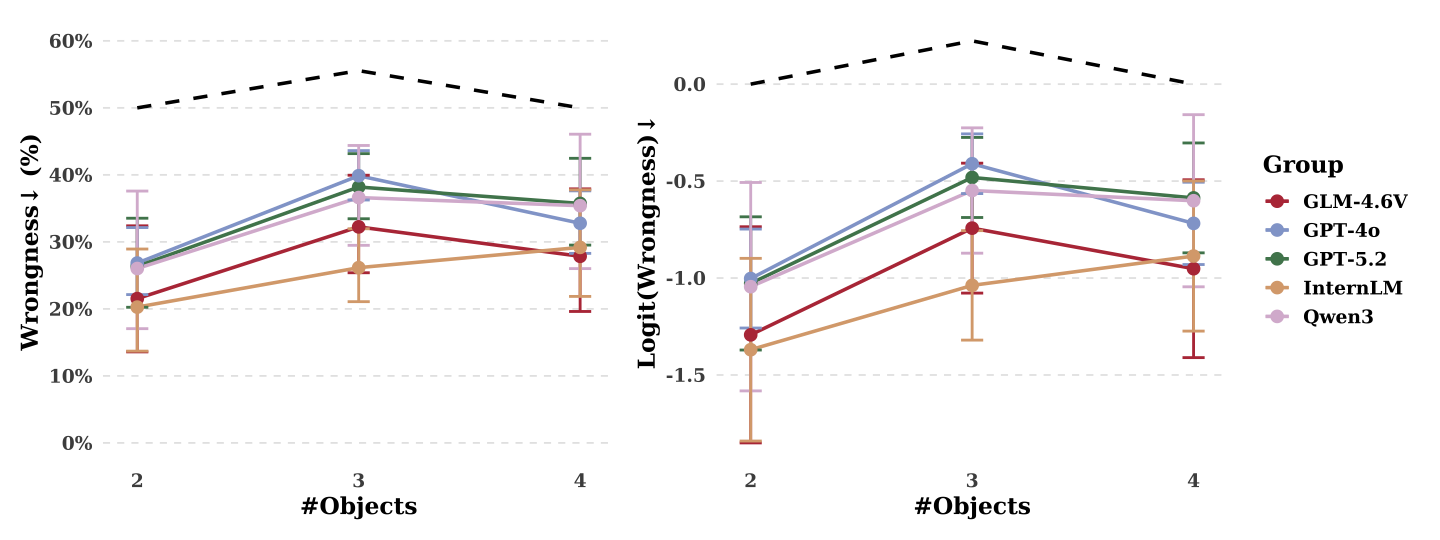

In [120]:
invlogit <- function(x) {
  1 / (1 + exp(-x))
}
plot_effect_from_link <- function(df_l, xvar, xlab, fname_base){
  # df_l contains predictions on the link scale (estimate, conf.low, conf.high)

  # Transform link scale predictions to response scale for p1
  df_r_transformed <- df_l %>%
    mutate(
      estimate_resp = invlogit(estimate),
      conf.low_resp = invlogit(conf.low),
      conf.high_resp = invlogit(conf.high)
    )

  # p1: Plot on response scale (derived from transformed link scale predictions)
  if (xvar == "n_candidates") {
    # Use expected wrongness baseline for n_candidates
    baseline_data_resp <- data.frame(
      x = c(2, 3, 4),
      y = c(baseline_wrongness_2, baseline_wrongness_3, baseline_wrongness_4)
    )
    p1 <- ggplot(df_r_transformed, aes(x=.data[[xvar]], y=estimate_resp,
                                   color=Group, fill=Group, group=Group)) +
      geom_line(linewidth=1) +
      geom_errorbar(aes(ymin=conf.low_resp, ymax=conf.high_resp),
                    width=0.1, linewidth=0.8) +
      geom_point(size=3) +
      geom_line(data=baseline_data_resp, aes(x=x, y=y, group=1),
                color='black', linetype='dashed', linewidth=1,
                inherit.aes=FALSE) +
      scale_color_manual(values=colors) +
      scale_fill_manual(values=colors) +
      scale_x_continuous(breaks = unique(as.integer(df_r_transformed[[xvar]]))) +
    scale_y_continuous(limits = c(0, 0.6),
                       breaks = seq(0, 0.6, by = 0.1),
                       labels = scales::percent_format(accuracy = 1)) +
      labs(x = xlab, y = "Wrongness↓ (%)") +
      theme_serif_bold() +
      theme(panel.grid.major.y = element_line(color="grey90", linetype="dashed", linewidth=0.5),
            panel.grid.major.x = element_blank(),
            legend.position = "none")
  } else {
    # Use overall baseline wrongness for Angle and Proximity
    prob_baseline_resp <- baseline_wrongness_overall
    p1 <- ggplot(df_r_transformed, aes(x=.data[[xvar]], y=estimate_resp,
                                   color=Group, fill=Group, group=Group)) +
      geom_line(linewidth=1) +
      geom_errorbar(aes(ymin=conf.low_resp, ymax=conf.high_resp),
                    width=0.1, linewidth=0.8) +
      geom_point(size=3) +
      geom_hline(yintercept=prob_baseline_resp, color='black', 
                 linetype='dashed', linewidth=1) +
      scale_color_manual(values=colors) +
      scale_fill_manual(values=colors)
    if (xvar == "Proximity") { 
        p1 <- p1 + scale_x_continuous(breaks = unique(as.integer(df_r_transformed[[xvar]])))
    }
    p1 <- p1 + scale_y_continuous(limits = c(0, 0.6),
                       breaks = seq(0, 0.6, by = 0.1),
                       labels = scales::percent_format(accuracy = 1)) +
      labs(x = xlab, y = "Wrongness↓ (%)") +
      theme_serif_bold() +
      theme(panel.grid.major.y = element_line(color="grey90", linetype="dashed", linewidth=0.5),
            panel.grid.major.x = element_blank(),
            legend.position = "none")
  }

  # p2: Plot on link scale (using original df_l)
  p2 <- ggplot(df_l, aes(x=.data[[xvar]], y=estimate,
                         color=Group, group=Group)) +
    geom_line(linewidth=1) +
    geom_errorbar(aes(ymin=conf.low, ymax=conf.high),
                  width=0.1, linewidth=0.8) +
    geom_point(size=3) +
    scale_color_manual(values=colors)
  
  if (xvar == "n_candidates") {
    # Logit baseline for wrongness
    logit_baseline_data <- data.frame(x = c(2, 3, 4))
    logit_baseline_data$y_logit <- log(c(baseline_wrongness_2, baseline_wrongness_3, baseline_wrongness_4) / 
                                       (1 - c(baseline_wrongness_2, baseline_wrongness_3, baseline_wrongness_4)))
    logit_baseline_data <- logit_baseline_data[is.finite(logit_baseline_data$y_logit), ]
    p2 <- p2 + geom_line(data=logit_baseline_data, aes(x=x, y=y_logit, group=1),
                         color='black', linetype='dashed', linewidth=1,
                         inherit.aes=FALSE)
  } else { 
    # Logit baseline for overall wrongness
    prob_baseline_link <- baseline_wrongness_overall
    logit_intercept <- log(prob_baseline_link / (1 - prob_baseline_link))
    p2 <- p2 + geom_hline(yintercept=logit_intercept, color='black',
                           linetype='dashed', linewidth=1)
  }

  if (xvar %in% c("Proximity", "n_candidates")) { 
      p2 <- p2 + scale_x_continuous(breaks = unique(as.integer(df_l[[xvar]])))
  }
  p2 <- p2 + labs(x = xlab, y = "Logit(Wrongness)↓") +
    theme_serif_bold() +
    theme(panel.grid.major.y = element_line(color="grey90", linetype="dashed", linewidth=0.5),
          panel.grid.major.x = element_blank(),
          legend.position = "right")

  combined <- p1 + p2 +
    plot_layout(ncol = 2)

  pdf(fname_base, width=12, height=4.5)
  print(combined)
  dev.off()
  options(repr.plot.width = 12, repr.plot.height = 4.5)
  print(combined)
}

plot_effect_from_link(ang_link,  "Angle", "View", "./plots/Angle_effect.pdf")
plot_effect_from_link(prox_link, "Proximity", "Proximity", "./plots/Proximity_effect.pdf")
plot_effect_from_link(obj_link,  "n_candidates", "#Objects", "./plots/n_candidates_effect.pdf")

pdf 
  2

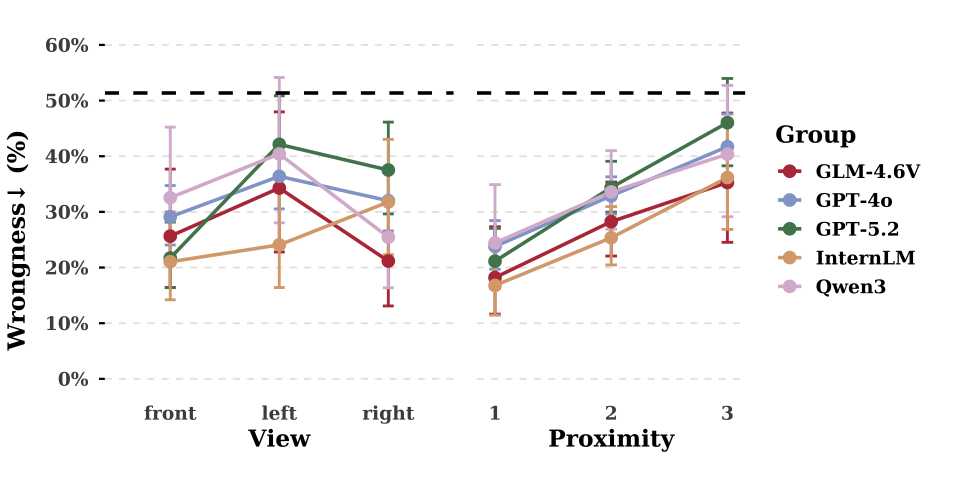

In [121]:
plot_single_effect <- function(df_l, xvar, xlab, show_y_axis = TRUE) {
  df_r_transformed <- df_l %>%
    mutate(
      estimate_resp = invlogit(estimate),
      conf.low_resp = invlogit(conf.low),
      conf.high_resp = invlogit(conf.high)
    )

  base_plot <- ggplot(df_r_transformed, aes(x = .data[[xvar]], y = estimate_resp,
                                            color = Group, fill = Group, group = Group)) +
    geom_line(linewidth = 1) +
    geom_errorbar(aes(ymin = conf.low_resp, ymax = conf.high_resp),
                  width = 0.1, linewidth = 0.8) +
    geom_point(size = 3) +
    scale_color_manual(values = colors) +
    scale_fill_manual(values = colors) +
    scale_y_continuous(limits = c(0, 0.6),
                       breaks = seq(0, 0.6, by = 0.1),
                       labels = scales::percent_format(accuracy = 1)) +
    theme_serif_bold() +
    theme(
      panel.grid.major.y = element_line(color = "grey90", linetype = "dashed", linewidth = 0.5),
      panel.grid.major.x = element_blank(),
      axis.title.y = element_blank(),
      axis.text.y = if (show_y_axis) element_text() else element_blank(),
      axis.ticks.y = if (show_y_axis) element_line() else element_blank(),
      legend.position = "right"
    ) +
    labs(x = xlab)

  # Add baselines using expected wrongness
  if (xvar == "n_candidates") {
    base_plot <- base_plot +
      geom_line(data = data.frame(x = c(2, 3, 4), 
                                  y = c(baseline_wrongness_2, baseline_wrongness_3, baseline_wrongness_4)),
                aes(x = x, y = y),
                color = 'black', linetype = 'dashed', linewidth = 1,
                inherit.aes = FALSE)
  } else if (xvar == "Proximity") {
    base_plot <- base_plot +
      geom_hline(yintercept = baseline_wrongness_overall, color = 'black', linetype = 'dashed', linewidth = 1)
  } else if (xvar == "Angle") {
    base_plot <- base_plot +
      geom_hline(yintercept = baseline_wrongness_overall, color = 'black', linetype = 'dashed', linewidth = 1)
  }

  return(base_plot)
}

# Create plots individually
p1 <- plot_single_effect(ang_link,  "Angle", "View", show_y_axis = TRUE) + 
  labs(y = "Wrongness↓ (%)") + guides(color = "none", fill = "none")

p2 <- plot_single_effect(prox_link, "Proximity", "Proximity", show_y_axis = FALSE) + scale_x_continuous(breaks = c(1,2,3)) 

#p3 <- plot_single_effect(obj_link,  "n_candidates", "#Objects", show_y_axis = FALSE) + scale_x_continuous(breaks = c(1,2,3)) 

# Compose final plot with shared y-axis and single legend
final_plot <- p1 + p2 + 
  plot_layout(ncol = 2, widths = c(1.3, 1), guides = "collect") +
#  plot_layout(ncol = 3, widths = c(1.3, 1, 1), guides = "collect") +
  plot_annotation(
    theme = theme(
      legend.position = "right",
      legend.title = element_text(size = 13),
      legend.text = element_text(size = 10),
      plot.margin = margin(10, 10, 10, 20),
      plot.title.position = "plot",
      plot.tag = element_text(),
      plot.title = element_blank()
    )
  ) +
  patchwork::inset_element(
    ggplot() + 
      annotate("text", x = 0.5, y = 0.5, label = "Wrongness↓ (%)", angle = 90, size = 5, family = "DejaVuSerif", fontface = "bold") +
      theme_void(),
    left = -1.9, bottom = 0.05, right = 0.02, top = 0.95, align_to = "full"
  )

# Save
pdf("./plots/effects.pdf", width = 12 * 2/3, height = 4)
print(final_plot)
dev.off()

# Also show inline if needed
options(repr.plot.width = 12 * 2/3, repr.plot.height = 4)
print(final_plot)

## Approach 2: get marginal effects separately in logit and probability space (not recommended)
Forces the error bars to be symmetric (equal length up and down) in the probability space.

In [49]:
plot_effect <- function(df_r, df_l, xvar, xlab, fname){
  # Determine baseline type
  if (xvar == "n_candidates") {
    # Use expected wrongness baseline for n_candidates
    baseline_data <- data.frame(
      x = c(2, 3, 4),
      y = c(baseline_wrongness_2, baseline_wrongness_3, baseline_wrongness_4)
    )
    p1 <- ggplot(df_r, aes(x=.data[[xvar]], y=estimate,
                           color=Group, fill=Group, group=Group)) +
      geom_line(linewidth=1) +
      geom_errorbar(aes(ymin=conf.low, ymax=conf.high),
                    width=0.1, linewidth=0.8) +
      geom_point(size=3) +
      geom_line(data=baseline_data, aes(x=x, y=y, group=1),
                color='black', linetype='dashed', linewidth=1,
                inherit.aes=FALSE) +
      scale_color_manual(values=colors) +
      scale_fill_manual(values=colors) +
      scale_x_continuous(breaks = unique(as.integer(df_r[[xvar]]))) + # Ensure integer breaks
    scale_y_continuous(limits = c(0, 0.6),
                       breaks = seq(0, 0.6, by = 0.1),
                       labels = scales::percent_format(accuracy = 1)) +
      labs(x = xlab, y = "Probability(Wrong) (%)") +
      theme_serif_bold() +
      theme(panel.grid.major.y = element_line(color="grey90", linetype="dashed", linewidth=0.5),
            panel.grid.major.x = element_blank(),
            legend.position = "none")
  } else {
    # Use overall baseline wrongness for Angle and Proximity
    p1 <- ggplot(df_r, aes(x=.data[[xvar]], y=estimate,
                           color=Group, fill=Group, group=Group)) +
      geom_line(linewidth=1) +
      geom_errorbar(aes(ymin=conf.low, ymax=conf.high),
                    width=0.1, linewidth=0.8) +
      geom_point(size=3) +
      geom_hline(yintercept=baseline_wrongness_overall, color='black', 
                 linetype='dashed', linewidth=1) +
      scale_color_manual(values=colors) +
      scale_fill_manual(values=colors)
    if (xvar == "Proximity") { # Ensure integer breaks for Proximity
        p1 <- p1 + scale_x_continuous(breaks = unique(as.integer(df_r[[xvar]])))
    }
    p1 <- p1 + scale_y_continuous(limits = c(0, 0.6),
                       breaks = seq(0, 0.6, by = 0.1),
                       labels = scales::percent_format(accuracy = 1)) +
      labs(x = xlab, y = "Probability(Wrong) (%)") +
      theme_serif_bold() +
      theme(panel.grid.major.y = element_line(color="grey90", linetype="dashed", linewidth=0.5),
            panel.grid.major.x = element_blank(),
            legend.position = "none")
  }

  p2 <- ggplot(df_l, aes(x=.data[[xvar]], y=estimate,
                         color=Group, group=Group)) +
    geom_line(linewidth=1) +
    geom_errorbar(aes(ymin=conf.low, ymax=conf.high),
                  width=0.1, linewidth=0.8) +
    geom_point(size=3) +
    scale_color_manual(values=colors)
  
  # Add baseline to p2 (logit scale)
  if (xvar == "n_candidates") {
    # Logit baseline for wrongness
    logit_baseline_data <- data.frame(x = c(2, 3, 4))
    logit_baseline_data$y_logit <- log(c(baseline_wrongness_2, baseline_wrongness_3, baseline_wrongness_4) / 
                                       (1 - c(baseline_wrongness_2, baseline_wrongness_3, baseline_wrongness_4)))
    logit_baseline_data <- logit_baseline_data[is.finite(logit_baseline_data$y_logit), ]

    p2 <- p2 + geom_line(data=logit_baseline_data, aes(x=x, y=y_logit, group=1),
                         color='black', linetype='dashed', linewidth=1,
                         inherit.aes=FALSE)
  } else { # For Angle and Proximity
    prob_baseline <- baseline_wrongness_overall
    logit_intercept <- log(prob_baseline / (1 - prob_baseline))
    p2 <- p2 + geom_hline(yintercept=logit_intercept, color='black',
                           linetype='dashed', linewidth=1)
  }

  if (xvar %in% c("Proximity", "n_candidates")) { # Ensure integer breaks for Proximity and n_candidates
      p2 <- p2 + scale_x_continuous(breaks = unique(as.integer(df_l[[xvar]])))
  }
  p2 <- p2 + labs(x = xlab, y = "Logit(Wrong)") +
    theme_serif_bold() +
    theme(panel.grid.major.y = element_line(color="grey90", linetype="dashed", linewidth=0.5),
          panel.grid.major.x = element_blank(),
          legend.position = "right")

  # arrange side-by-side
  combined <- p1 + p2 +
    plot_layout(ncol = 2)

  # save pdf
  pdf(fname, width=12, height=4.5)
  print(combined)
  dev.off()
  # also print to screen
  options(repr.plot.width = 12, repr.plot.height = 4.5)
  print(combined)
}

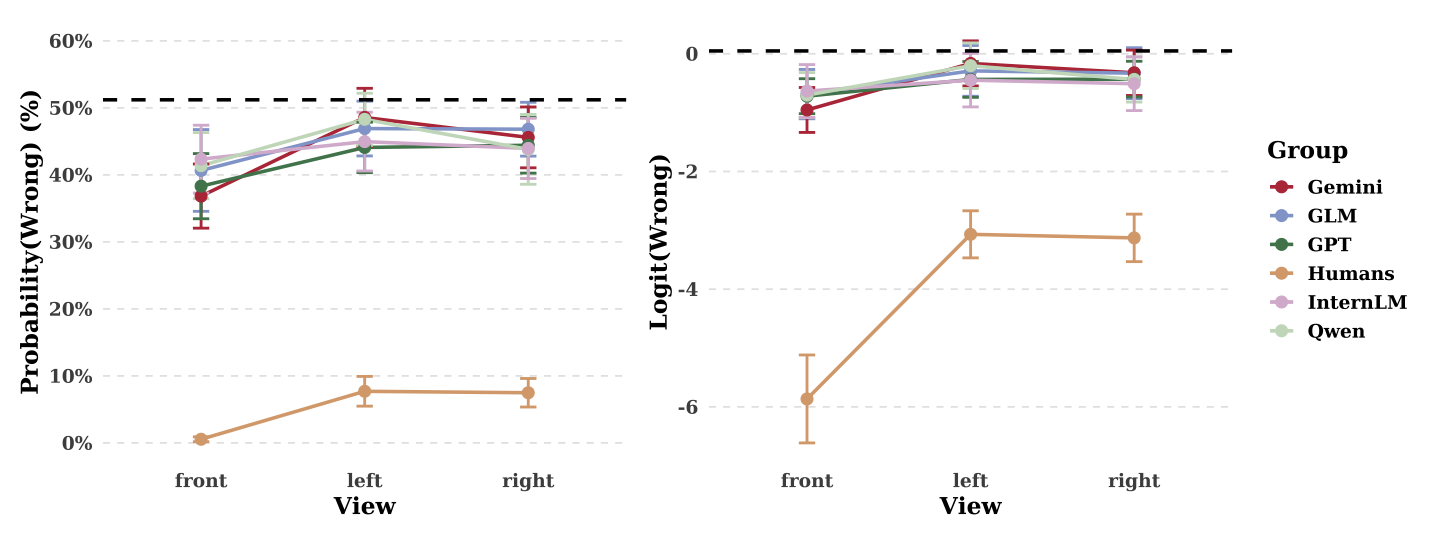

In [50]:
plot_effect(ang_resp,  ang_link,  "Angle",        "View",           "./plots/Angle_effect2.pdf")

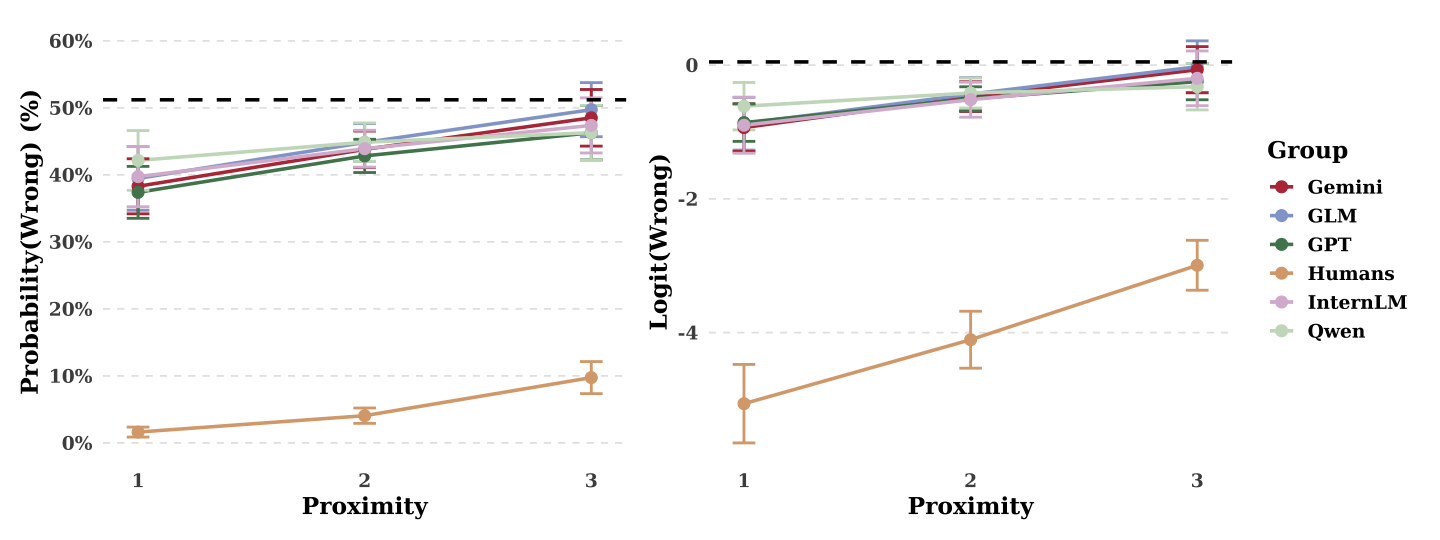

In [51]:
plot_effect(prox_resp, prox_link, "Proximity",    "Proximity",      "./plots/Proximity_effect2.pdf")

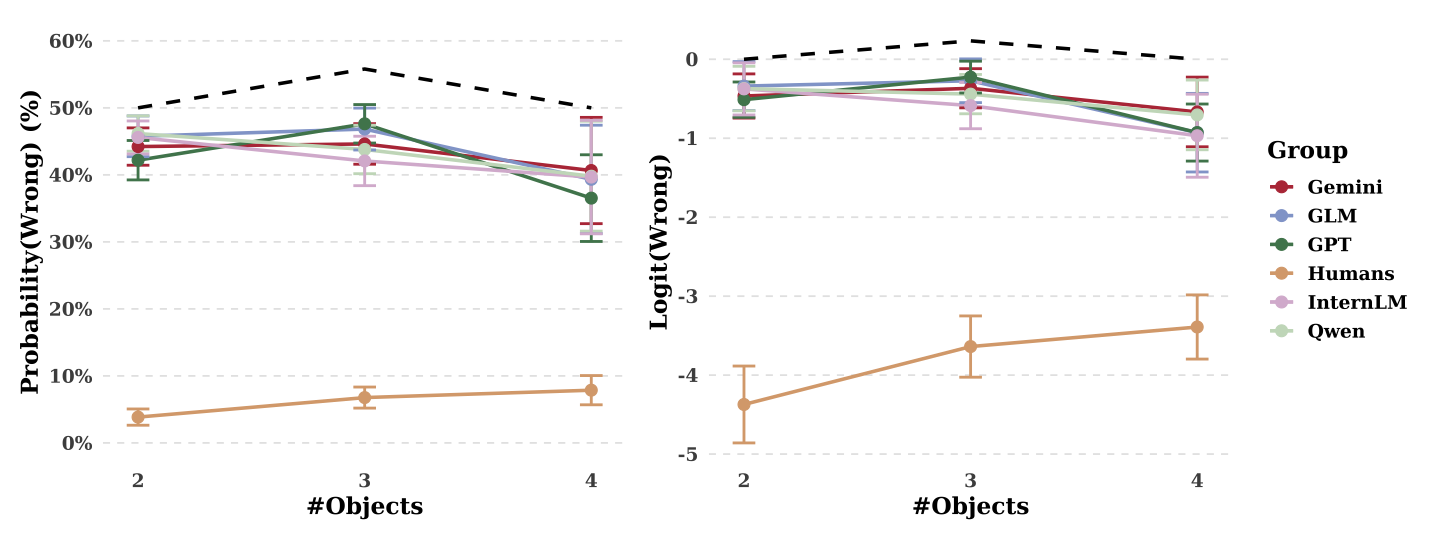

In [52]:
plot_effect(obj_resp,  obj_link,  "n_candidates", "#Objects",       "./plots/n_candidates_effect2.pdf")